<a href="https://colab.research.google.com/github/arsingla786/MLFromScratch/blob/main/feature_scaling_ANN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [44]:
df  = pd.read_csv('/content/age_salary_1000.csv')

In [45]:
df.head()

,age,salary,target
0,56,122916,1
1,46,132250,0
2,32,136553,1
3,60,63872,0
4,25,66197,0


In [46]:
X = df.iloc[:,0:2]
y = df.iloc[:,-1]

In [47]:
X.head()

,age,salary
0,56,122916
1,46,132250
2,32,136553
3,60,63872
4,25,66197


In [48]:
X.shape

(1000, 2)

In [49]:
y.head()

,target
0,1
1,0
2,1
3,0
4,0


In [50]:
y.shape

(1000,)

In [51]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=0,stratify=y)

##Without scaling

In [52]:
import tensorflow
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense

In [53]:
model = Sequential()

model.add(Dense(10,activation='relu',input_dim=2))
model.add(Dense(10,activation='relu'))
model.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [54]:
model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_12 (Dense)                │ (None, 10)             │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 151 (604.00 B)

 Trainable params: 151 (604.00 B)

 Non-trainable params: 0 (0.00 B)

In [55]:
model.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [56]:
history = model.fit(X_train,y_train,epochs=100,validation_data=(X_test,y_test),verbose=1)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.3475 - loss: 13069.5508 - val_accuracy: 0.3450 - val_loss: 9767.0205
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3475 - loss: 8026.3350 - val_accuracy: 0.3450 - val_loss: 5119.4282
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.3475 - loss: 3157.3569 - val_accuracy: 0.3450 - val_loss: 580.5724
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5975 - loss: 388.2157 - val_accuracy: 0.3450 - val_loss: 37.1161
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4925 - loss: 75.6406 - val_accuracy: 0.6550 - val_loss: 44.1376
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.5000 - loss: 15.2100 - val_accuracy: 0.3450 - val_loss: 14.2983
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.5337 - loss: 9.9997 - val_accuracy: 0.3450 - val_loss: 22.6714
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.4825 - loss: 21.345

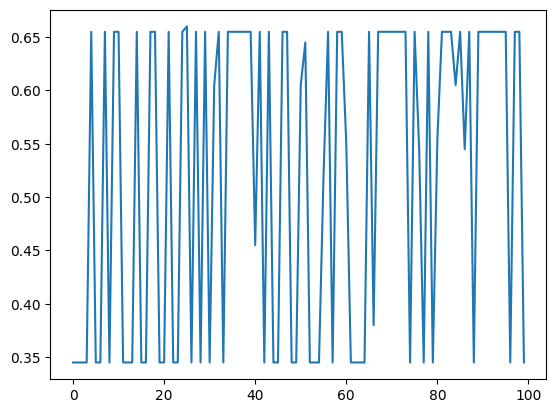

In [57]:
plt.plot(history.history['val_accuracy'])

##Now without scaling  the validation accuracy keeps jumping in 63 and 37

##Feature Scaling

In [58]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()

X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [59]:
model2 = Sequential()

model2.add(Dense(10,activation='relu',input_dim=2))
model2.add(Dense(10,activation='relu'))
model2.add(Dense(1,activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [60]:
model2.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [61]:
history2 = model2.fit(X_train_scaled,y_train,epochs=100,validation_data=(X_test_scaled,y_test),verbose=1)

Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.7225 - loss: 0.6648 - val_accuracy: 0.7400 - val_loss: 0.6414
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7175 - loss: 0.6379 - val_accuracy: 0.7250 - val_loss: 0.6140
Epoch 3/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7013 - loss: 0.6163 - val_accuracy: 0.7200 - val_loss: 0.5914
Epoch 4/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7000 - loss: 0.5970 - val_accuracy: 0.7150 - val_loss: 0.5736
Epoch 5/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7075 - loss: 0.5811 - val_accuracy: 0.7200 - val_loss: 0.5580
Epoch 6/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7275 - loss: 0.5676 - val_accuracy: 0.7500 - val_loss: 0.5462
Epoch 7/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7212 - loss: 0.5562 - val_accuracy: 0.7500 - val_loss: 0.5373
Epoch 8/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7300 - loss: 0.5475 - val_accuracy: 0.7450 - 

/tmp/ipykernel_1499/2350695292.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


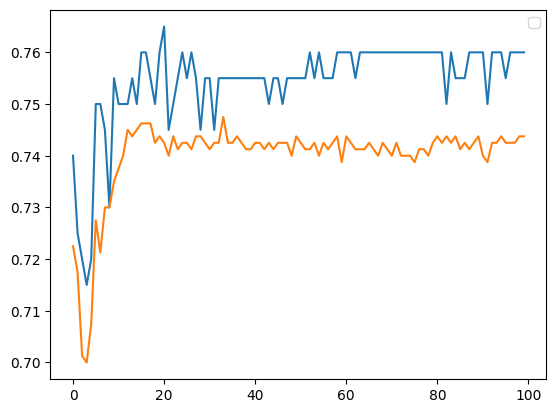

In [62]:
plt.plot(history2.history['val_accuracy'])
plt.plot(history2.history['accuracy'])
plt.legend()

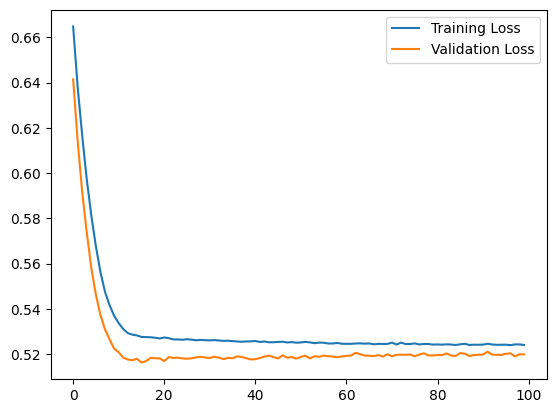

In [63]:
plt.plot(history2.history['loss'], label='Training Loss')
plt.plot(history2.history['val_loss'], label='Validation Loss')
plt.legend()
plt.show()

#using scaling + early stopping to increse model performance

In [64]:
model3 = Sequential()

model3.add(Dense(20,activation='relu',input_dim=2))
model3.add(Dense(20,activation='relu'))
model3.add(Dense(1,activation='sigmoid'))

In [65]:
model3.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [66]:
from keras.callbacks import EarlyStopping
callbacks = EarlyStopping(
    monitor = 'val_loss',
    min_delta = 0.0001,
    patience = 20,
    verbose = 1,
    mode = 'auto',
    baseline = None,
    restore_best_weights = True
)

In [67]:
history3 = model3.fit(X_train_scaled,y_train,epochs=200,validation_data=(X_test_scaled,y_test),verbose=1,callbacks=callbacks)


Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.6600 - loss: 0.6650 - val_accuracy: 0.6950 - val_loss: 0.6315
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7138 - loss: 0.6163 - val_accuracy: 0.7300 - val_loss: 0.5869
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7225 - loss: 0.5816 - val_accuracy: 0.7400 - val_loss: 0.5538
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7300 - loss: 0.5563 - val_accuracy: 0.7300 - val_loss: 0.5358
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7337 - loss: 0.5422 - val_accuracy: 0.7450 - val_loss: 0.5269
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7387 - loss: 0.5372 - val_accuracy: 0.7550 - val_loss: 0.5245
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7412 - loss: 0.5331 - val_accuracy: 0.7550 - val_loss: 0.5223
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7412 - loss: 0.5316 - val_accuracy: 0.7550 - 

In [68]:
#model 4
model4 = Sequential()

model4.add(Dense(32,activation='relu',input_dim=2))
model4.add(Dense(16,activation='relu'))
model4.add(Dense(8,activation='relu'))
model4.add(Dense(1,activation='sigmoid'))

In [69]:
model4.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

In [70]:
model4.fit(X_train_scaled,y_train,epochs=200,validation_data=(X_test_scaled,y_test),verbose=1,callbacks=callbacks)

Epoch 1/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - accuracy: 0.6000 - loss: 0.6603 - val_accuracy: 0.7350 - val_loss: 0.6130
Epoch 2/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7362 - loss: 0.5893 - val_accuracy: 0.7550 - val_loss: 0.5531
Epoch 3/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7362 - loss: 0.5501 - val_accuracy: 0.7500 - val_loss: 0.5262
Epoch 4/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7400 - loss: 0.5379 - val_accuracy: 0.7500 - val_loss: 0.5234
Epoch 5/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7412 - loss: 0.5323 - val_accuracy: 0.7600 - val_loss: 0.5230
Epoch 6/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7387 - loss: 0.5306 - val_accuracy: 0.7450 - val_loss: 0.5194
Epoch 7/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7400 - loss: 0.5304 - val_accuracy: 0.7500 - val_loss: 0.5209
Epoch 8/200
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7387 - loss: 0.5291 - val_accuracy: 0.7550 - 

In [71]:
print(y.value_counts())

target
0    653
1    347
Name: count, dtype: int64


In [83]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = (model3.predict(X_test_scaled) > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
[[113  18]
 [ 30  39]]
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       131
           1       0.68      0.57      0.62        69

    accuracy                           0.76       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.75      0.76      0.75       200



In [80]:
print(np.unique(y_pred, return_counts=True))

(array([1]), array([200]))


In [81]:
y_prob3 = model3.predict(X_test_scaled)

print(y_prob3[:20])
print(np.unique((y_prob3 > 0.5).astype(int), return_counts=True))
print(np.unique(y_test, return_counts=True))
print(model3.evaluate(X_test_scaled, y_test))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
[[0.31123295]
 [0.06294508]
 [0.60473573]
 [0.5686185 ]
 [0.603094  ]
 [0.21366738]
 [0.11815132]
 [0.54559636]
 [0.1179785 ]
 [0.31055894]
 [0.4688234 ]
 [0.07102948]
 [0.11801767]
 [0.64738894]
 [0.73018736]
 [0.6750411 ]
 [0.26406506]
 [0.5772722 ]
 [0.03089128]
 [0.05214901]]
(array([0, 1]), array([143,  57]))
(array([0, 1]), array([131,  69]))
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7600 - loss: 0.5170 
[0.5170431137084961, 0.7599999904632568]


In [82]:
y_prob3 = model3.predict(X_test_scaled)

y_pred3 = (y_prob3 > 0.5).astype(int)

print(confusion_matrix(y_test, y_pred3))
print(classification_report(y_test, y_pred3))

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
[[113  18]
 [ 30  39]]
              precision    recall  f1-score   support

           0       0.79      0.86      0.82       131
           1       0.68      0.57      0.62        69

    accuracy                           0.76       200
   macro avg       0.74      0.71      0.72       200
weighted avg       0.75      0.76      0.75       200

